# Non-isothermal reactors: the energy balance

For an exothermic reaction the temperature is an unknown coupled to the kinetics (Arrhenius) and thermodynamics. We carry temperature as a variable (CSTR) or a spatial state (PFR) with an adiabatic energy balance. Units here are SI (J/mol, `R = 8.314`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root for discopt_mkm

## Adiabatic CSTR

A simple exothermic `A -> B` on a catalyst. The steady-state temperature rises above the feed temperature; an isothermal solve *at* the solved temperature reproduces the same conversion (energy-balance self-consistency).

In [2]:
import numpy as np, discopt_mkm as mk
from discopt_mkm.examples import adiabatic_cstr
from discopt_mkm.energy import EnergyBalance

m, reactor, energy = adiabatic_cstr(T_in=500.0)
A, B = m._by_name['A'], m._by_name['B']
sol = mk.solve_steady_state(m, reactor, energy=energy)
print(f'status={sol.status}')
print(f'  T_in=500 K -> T_out={sol.temperature():.1f} K')
print(f'  conversion = {1.0 - sol.gas_concentration(A):.3f}')

status=optimal
  T_in=500 K -> T_out=835.7 K
  conversion = 0.839


## Adiabatic PFR

Temperature is a spatial state; it rises along the reactor as A converts.

In [3]:
m2, _, _ = adiabatic_cstr(T_in=500.0)
A2, B2 = m2._by_name['A'], m2._by_name['B']
pfr = mk.solve_pfr(m2, {A2: 1.0, B2: 0.0}, length=1.0, velocity=1.0, cat_density=0.02,
                   nfe=10, ncp=3, energy=EnergyBalance(T_in=500.0))
Tz = np.asarray(pfr.temperature()).reshape(-1)
print(f'status={pfr.status}')
print(f'  T: {Tz[0]:.1f} K (inlet) -> {pfr.outlet_temperature():.1f} K (outlet)')
print(f'  conversion = {pfr.conversion(A2):.3f}')

status=optimal
  T: 500.5 K (inlet) -> 565.2 K (outlet)
  conversion = 0.163


## Isothermal vs adiabatic along the PFR

Solving the same reactor with no energy balance (isothermal, held at the feed temperature) and with the adiabatic energy balance shows the feedback: the exotherm heats the gas, the rate constant climbs, and conversion runs ahead of the isothermal case.

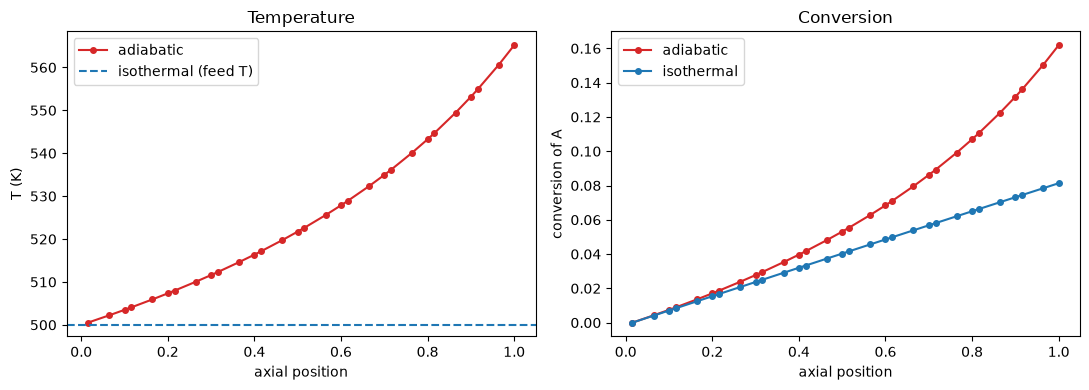

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
iso = mk.solve_pfr(m2, {A2: 1.0, B2: 0.0}, length=1.0, velocity=1.0,
                   cat_density=0.02, nfe=10, ncp=3)   # no energy -> isothermal
z = pfr.positions()
cA_ad, cA_iso = pfr.concentration(A2), iso.concentration(A2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, pfr.temperature(), 'C3-o', ms=4, label='adiabatic')
ax[0].axhline(500.0, color='C0', ls='--', label='isothermal (feed T)')
ax[0].set_xlabel('axial position'); ax[0].set_ylabel('T (K)')
ax[0].legend(); ax[0].set_title('Temperature')
ax[1].plot(z, 1 - cA_ad / cA_ad[0], 'C3-o', ms=4, label='adiabatic')
ax[1].plot(z, 1 - cA_iso / cA_iso[0], 'C0-o', ms=4, label='isothermal')
ax[1].set_xlabel('axial position'); ax[1].set_ylabel('conversion of A')
ax[1].legend(); ax[1].set_title('Conversion')
fig.tight_layout()
